# Bengali Sign Language Detection — Model Training
**Dataset:** [Bengali Sign Language Dataset by muntakimrafi](https://www.kaggle.com/datasets/muntakimrafi/bengali-sign-language-dataset)

### Improvements over original:
- Removed duplicate `import tensorflow as tf` (was imported 3x)
- Fixed Kaggle dataset download to Bengali Sign Language
- Removed deprecated TF1-style `InteractiveSession` / `GPUOptions`
- Added `BatchNormalization` + `Dropout` to reduce overfitting
- Added `EarlyStopping`, `ModelCheckpoint`, `ReduceLROnPlateau` callbacks
- Added `ImageDataGenerator` data augmentation
- Switched model save format from `.h5` (deprecated) to `.keras`
- Stratified train/test split for balanced class distribution
- Fixed sample visualisation bug (one-hot to int decoding)
- Auto-generated class map from actual folder names

## 1. Install Dependencies

In [ ]:
!pip install -q kaggle visualkeras ann-visualizer

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.1 MB/s eta 0:00:00


## 2. Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn import metrics

import visualkeras

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {tf.config.list_physical_devices('GPU')}")

TensorFlow version : 2.20.0
GPU available      : []


## 3. Kaggle Setup & Dataset Download

**Option A** - Upload kaggle.json directly (need to re-upload every session)

**Option B** - Load from Google Drive (recommended - one time setup)

To get your kaggle.json: Kaggle Profile > Settings > API > Create New Token

In [ ]:
import os
from google.colab import drive

# Mount Google Drive to the standard location
drive.mount('/content/drive')

# Ensure the .kaggle directory exists
os.makedirs('/root/.kaggle', exist_ok=True)

# Copy kaggle.json from Google Drive to the .kaggle directory
!cp /content/drive/MyDrive/kaggle/kaggle.json /root/.kaggle/kaggle.json

# Set appropriate permissions for the kaggle.json file
os.chmod('/root/.kaggle/kaggle.json', 0o600)

print('Kaggle credentials configured.')

Mounted at /content/drive
Kaggle credentials configured.


In [ ]:
# Download Bengali Sign Language Dataset
!kaggle datasets download -d muntakimrafi/bengali-sign-language-dataset

!mkdir -p dataset
!unzip -q bengali-sign-language-dataset.zip -d dataset

print('Dataset downloaded and extracted.')

Dataset URL: https://www.kaggle.com/datasets/muntakimrafi/bengali-sign-language-dataset
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100% 188M/188M [00:01<00:00, 129MB/s]

Dataset downloaded and extracted.


In [ ]:
# Run this to see the exact folder structure after extraction
!ls dataset/
!echo '---'
!ls dataset/Bengali 2>/dev/null || echo 'Folder name may be different - check ls dataset/ output above and update DATA_FOLDER below'

RESIZED_DATASET  RESIZED_TESTING_DATA
---
Folder name may be different - check ls dataset/ output above and update DATA_FOLDER below


In [ ]:
# Update this path if the folder name shown above is different
DATA_FOLDER = '/content/dataset/RESIZED_DATASET'

classes_found = sorted(os.listdir(DATA_FOLDER))
NUM_CLASSES   = len(classes_found)
print(f'Classes found ({NUM_CLASSES}):')
print(classes_found)

Classes found (38):
['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '4', '5', '6', '7', '8', '9']


## 4. Class Map
Auto-generated from actual folder names — no manual editing needed.

In [ ]:
map_characters = {i: name for i, name in enumerate(classes_found)}
class_labels   = list(map_characters.values())

print(f'Total classes : {NUM_CLASSES}')
print(f'Class map     : {map_characters}')

Total classes : 38
Class map     : {0: '0', 1: '1', 2: '10', 3: '11', 4: '12', 5: '13', 6: '14', 7: '15', 8: '16', 9: '17', 10: '18', 11: '19', 12: '2', 13: '20', 14: '21', 15: '22', 16: '23', 17: '24', 18: '25', 19: '26', 20: '27', 21: '28', 22: '29', 23: '3', 24: '30', 25: '31', 26: '32', 27: '33', 28: '34', 29: '35', 30: '36', 31: '37', 32: '4', 33: '5', 34: '6', 35: '7', 36: '8', 37: '9'}


## 5a. Data Analysis — Class Distribution & Image Counts
Fully addresses **Section 2.5.1**: total images per class, class distribution chart.

Total images in dataset : 11061
Number of classes       : 38
Average images/class    : 291.1
Min images in any class : 246 (4)
Max images in any class : 300 (22)


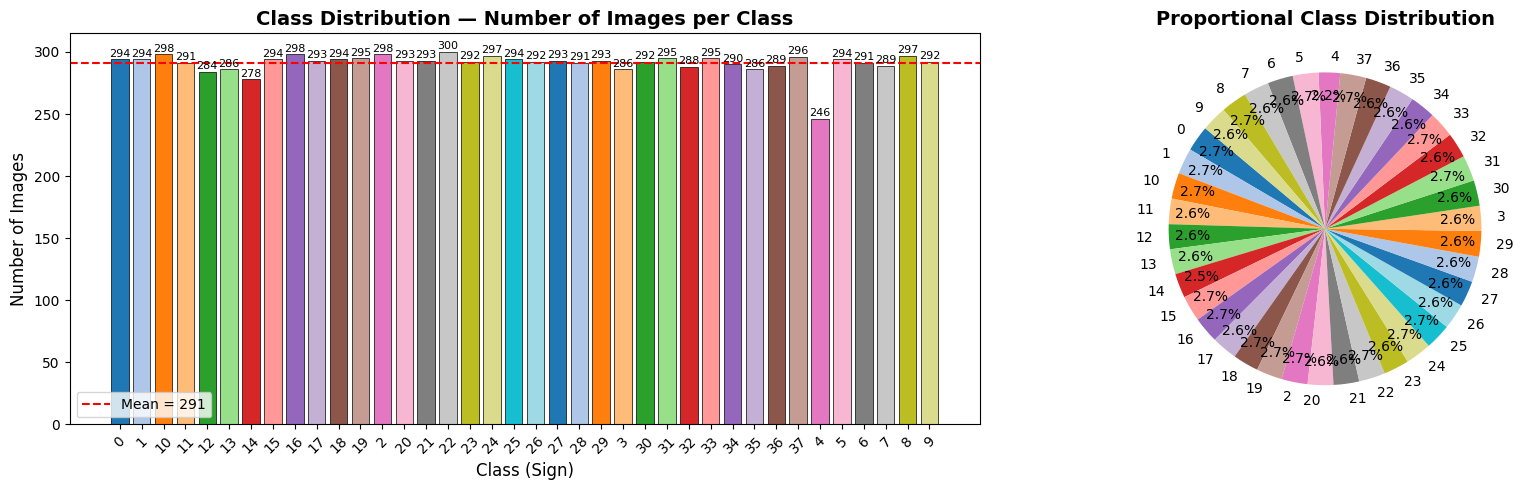

Class distribution saved as class_distribution.png


In [ ]:
# ── Count images per class ──────────────────────────────────────────────────
class_counts = {}
for cls_name in classes_found:
    cls_path = os.path.join(DATA_FOLDER, cls_name)
    if os.path.isdir(cls_path):
        class_counts[cls_name] = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
        ])

total_images = sum(class_counts.values())
print(f"Total images in dataset : {total_images}")
print(f"Number of classes       : {len(class_counts)}")
print(f"Average images/class    : {total_images/len(class_counts):.1f}")
print(f"Min images in any class : {min(class_counts.values())} ({min(class_counts, key=class_counts.get)})")
print(f"Max images in any class : {max(class_counts.values())} ({max(class_counts, key=class_counts.get)})")

# ── Class Distribution Bar Chart ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Bar chart
ax = axes[0]
bars = ax.bar(list(class_counts.keys()), list(class_counts.values()),
              color=plt.cm.tab20.colors[:len(class_counts)], edgecolor='black', linewidth=0.5)
ax.set_title('Class Distribution — Number of Images per Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Class (Sign)', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.axhline(total_images / len(class_counts), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean = {total_images/len(class_counts):.0f}')
ax.legend()
ax.tick_params(axis='x', rotation=45)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)

# Pie chart
ax2 = axes[1]
ax2.pie(list(class_counts.values()), labels=list(class_counts.keys()),
        autopct='%1.1f%%', startangle=140,
        colors=plt.cm.tab20.colors[:len(class_counts)], pctdistance=0.85)
ax2.set_title('Proportional Class Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Class distribution saved as class_distribution.png")


## 5. Image Loading & Preprocessing

In [ ]:
IMAGE_SIZE = 64

def edge_detection(image):
    """Apply Gaussian blur + adaptive threshold to highlight hand edges."""
    min_val = 70
    blur = cv2.GaussianBlur(image, (5, 5), 2)
    th3  = cv2.adaptiveThreshold(
        blur, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 11, 2
    )
    _, res = cv2.threshold(
        th3, min_val, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )
    return res


def load_images(data_folder=DATA_FOLDER, img_size=IMAGE_SIZE):
    """Load all images, apply edge detection, normalise to [0,1]."""
    images, labels = [], []
    folders = sorted(os.listdir(data_folder))

    for index, folder in enumerate(folders):
        folder_path = os.path.join(data_folder, folder)
        if not os.path.isdir(folder_path):
            continue
        print(f'[{index+1}/{len(folders)}] Loading "{folder}" ...')
        for fname in os.listdir(folder_path):
            img = cv2.imread(os.path.join(folder_path, fname), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = edge_detection(img)
            img = cv2.resize(img, (img_size, img_size))
            images.append(img_to_array(img))
            labels.append(index)

    images = np.array(images, dtype='float32') / 255.0
    labels = to_categorical(labels, num_classes=len(folders))

    x_train, x_test, y_train, y_test = train_test_split(
        images, labels,
        test_size=0.2, random_state=42, stratify=labels
    )
    print(f'\nDone - Train: {x_train.shape}  |  Test: {x_test.shape}')
    return x_train, x_test, y_train, y_test

In [ ]:
x_train, x_test, y_train, y_test = load_images()

[1/38] Loading "0" ...
[2/38] Loading "1" ...
[3/38] Loading "10" ...
[4/38] Loading "11" ...
[5/38] Loading "12" ...
[6/38] Loading "13" ...
[7/38] Loading "14" ...
[8/38] Loading "15" ...
[9/38] Loading "16" ...
[10/38] Loading "17" ...
[11/38] Loading "18" ...
[12/38] Loading "19" ...
[13/38] Loading "2" ...
[14/38] Loading "20" ...
[15/38] Loading "21" ...
[16/38] Loading "22" ...
[17/38] Loading "23" ...
[18/38] Loading "24" ...
[19/38] Loading "25" ...
[20/38] Loading "26" ...
[21/38] Loading "27" ...
[22/38] Loading "28" ...
[23/38] Loading "29" ...
[24/38] Loading "3" ...
[25/38] Loading "30" ...
[26/38] Loading "31" ...
[27/38] Loading "32" ...
[28/38] Loading "33" ...
[29/38] Loading "34" ...
[30/38] Loading "35" ...
[31/38] Loading "36" ...
[32/38] Loading "37" ...
[33/38] Loading "4" ...
[34/38] Loading "5" ...
[35/38] Loading "6" ...
[36/38] Loading "7" ...
[37/38] Loading "8" ...
[38/38] Loading "9" ...

Done - Train: (8848, 64, 64, 1)  |  Test: (2213, 64, 64, 1)


In [ ]:
x_train, y_train = shuffle(x_train, y_train, random_state=17)
x_test,  y_test  = shuffle(x_test,  y_test,  random_state=17)
print('Data shuffled.')

Data shuffled.


## 6. Sample Visualisation

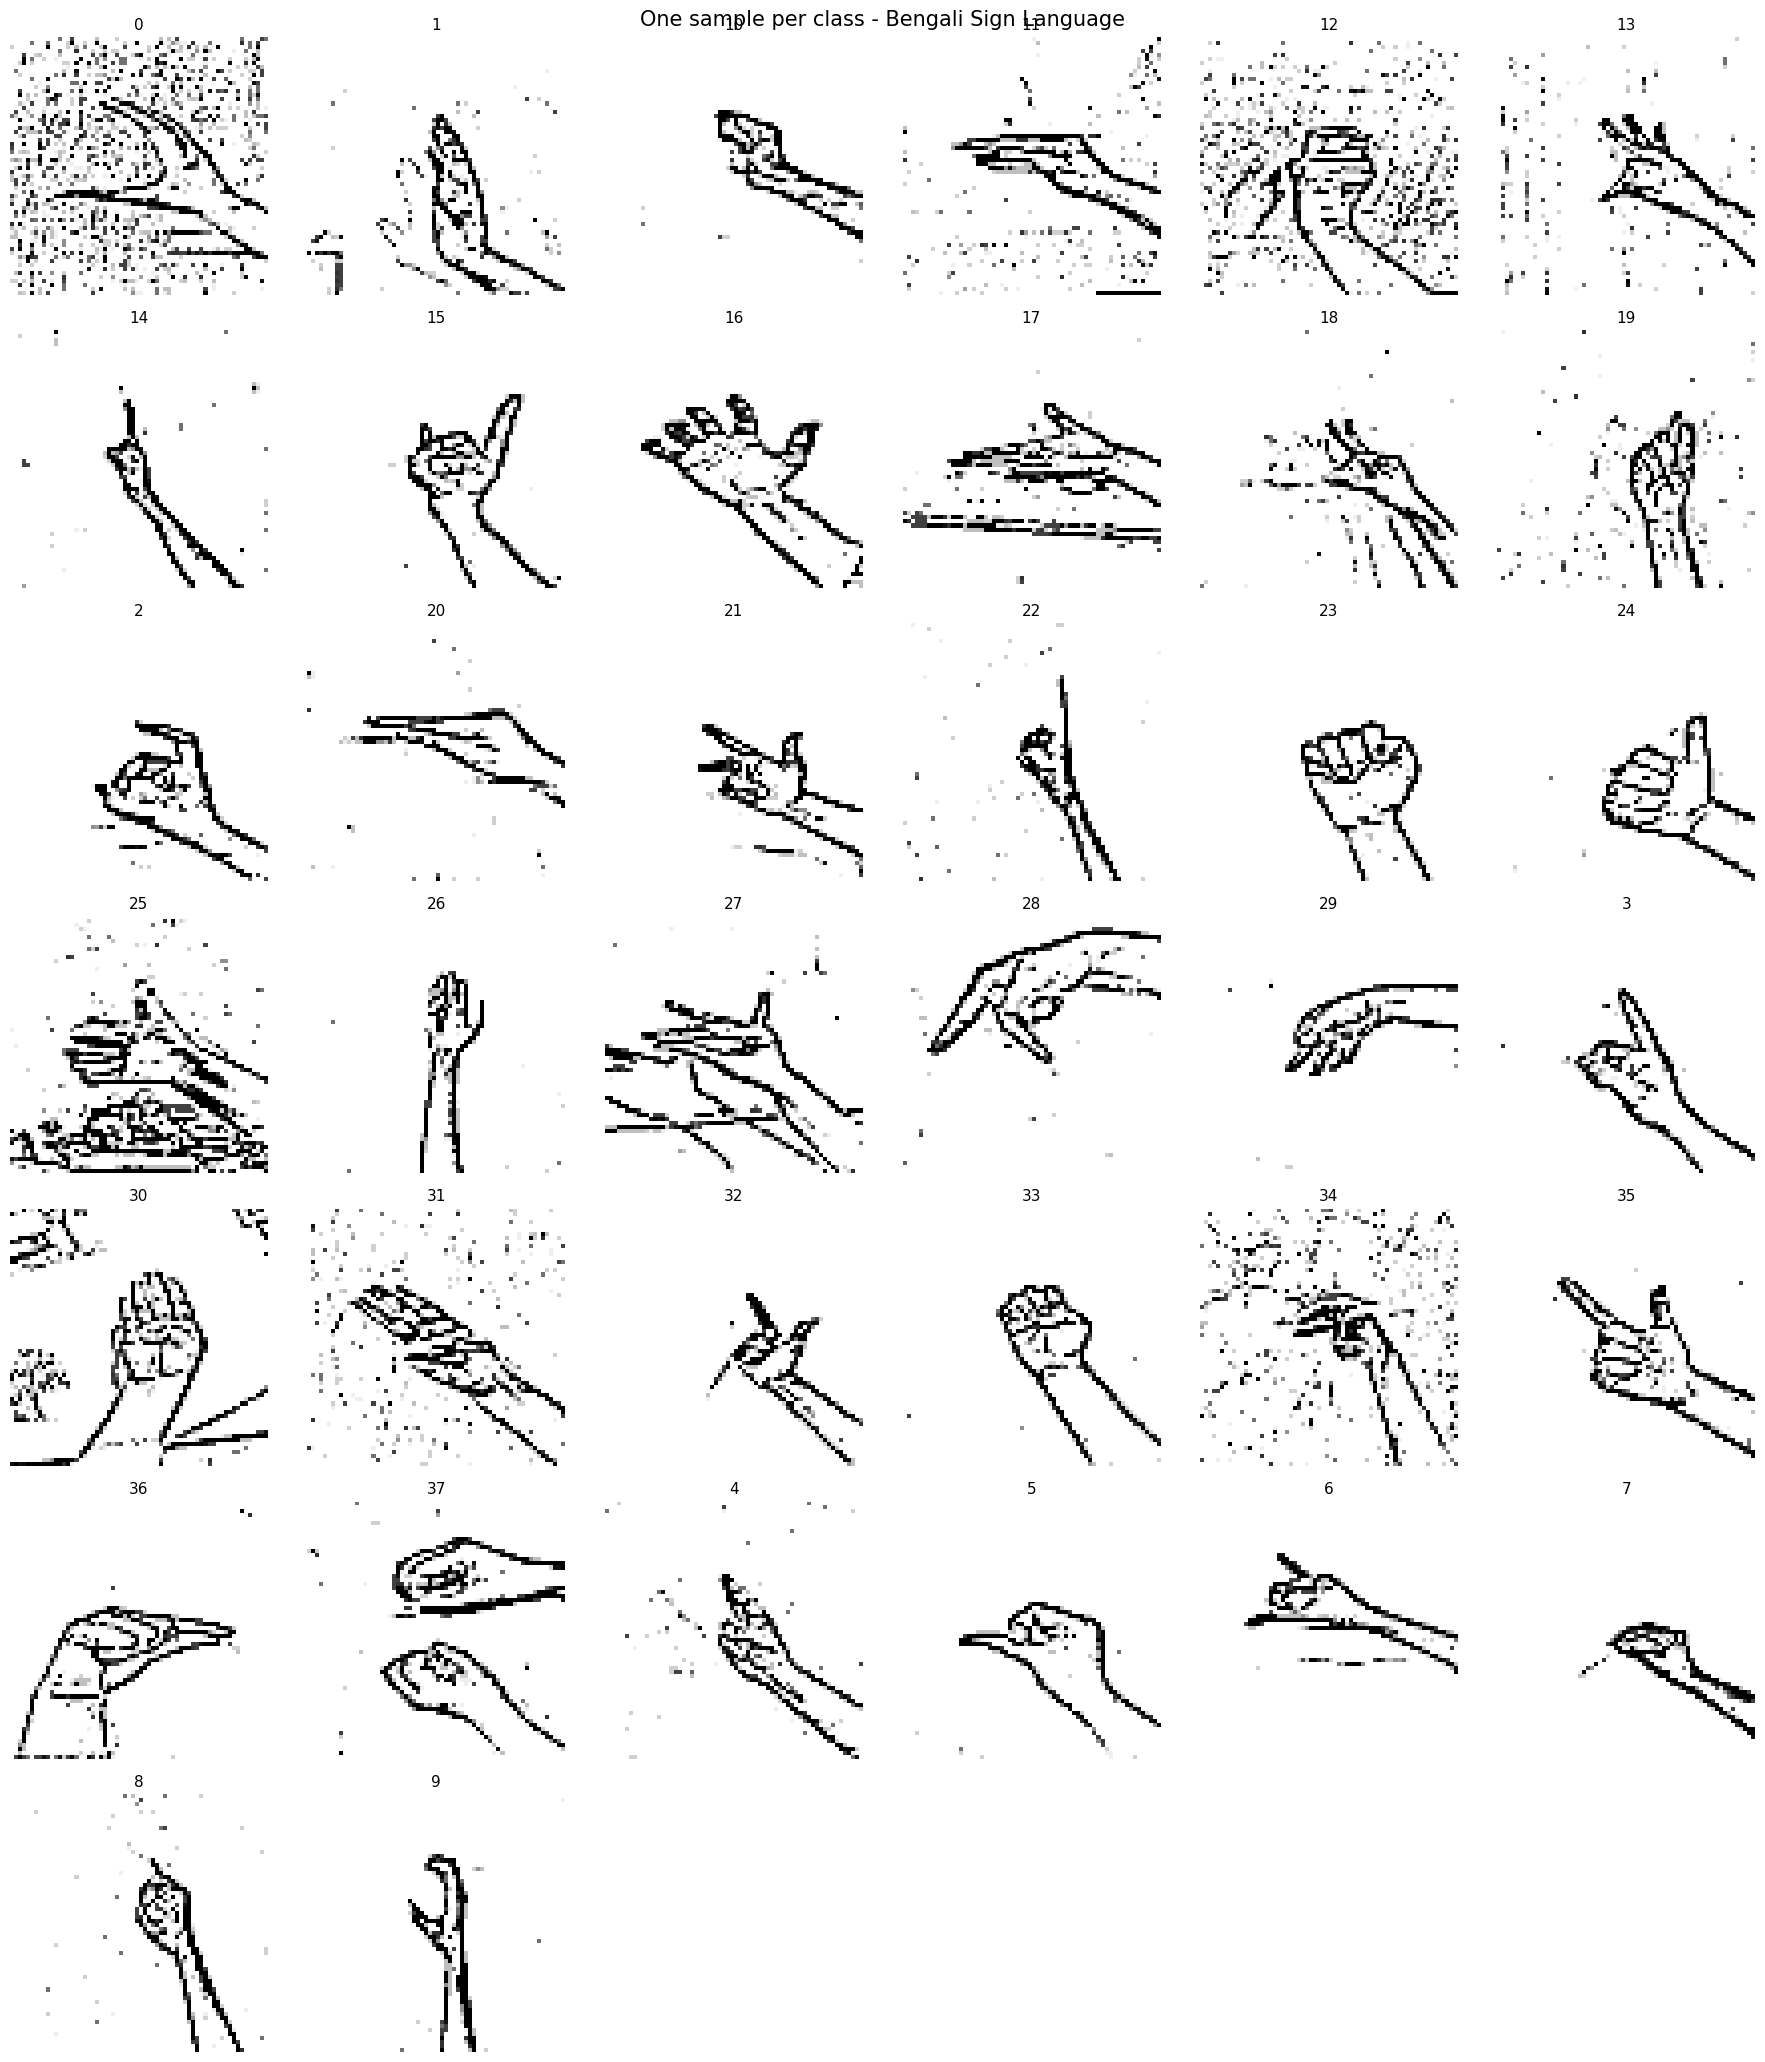

In [ ]:
y_train_int = np.argmax(y_train, axis=1)  # one-hot to integer

cols = 6
rows = int(np.ceil(NUM_CLASSES / cols))
plt.figure(figsize=(cols * 3, rows * 3))

for idx, label in enumerate(sorted(np.unique(y_train_int))):
    sample_idx = np.where(y_train_int == label)[0][0]
    plt.subplot(rows, cols, idx + 1)
    plt.imshow(x_train[sample_idx].squeeze(), cmap='gray')
    plt.title(map_characters[label], fontsize=11)
    plt.axis('off')

plt.suptitle('One sample per class - Bengali Sign Language', fontsize=15)
plt.tight_layout()
plt.show()

## 7. Data Augmentation
Applied only to the training set — test set is left unchanged.

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False  # False because flipped hands change meaning in sign language
)
datagen.fit(x_train)
print('Augmentation generator ready.')

Augmentation generator ready.


## 7a. Augmented Image Visualisation
Displays original vs augmented samples for the same image — required by **Section 2.5.1**.

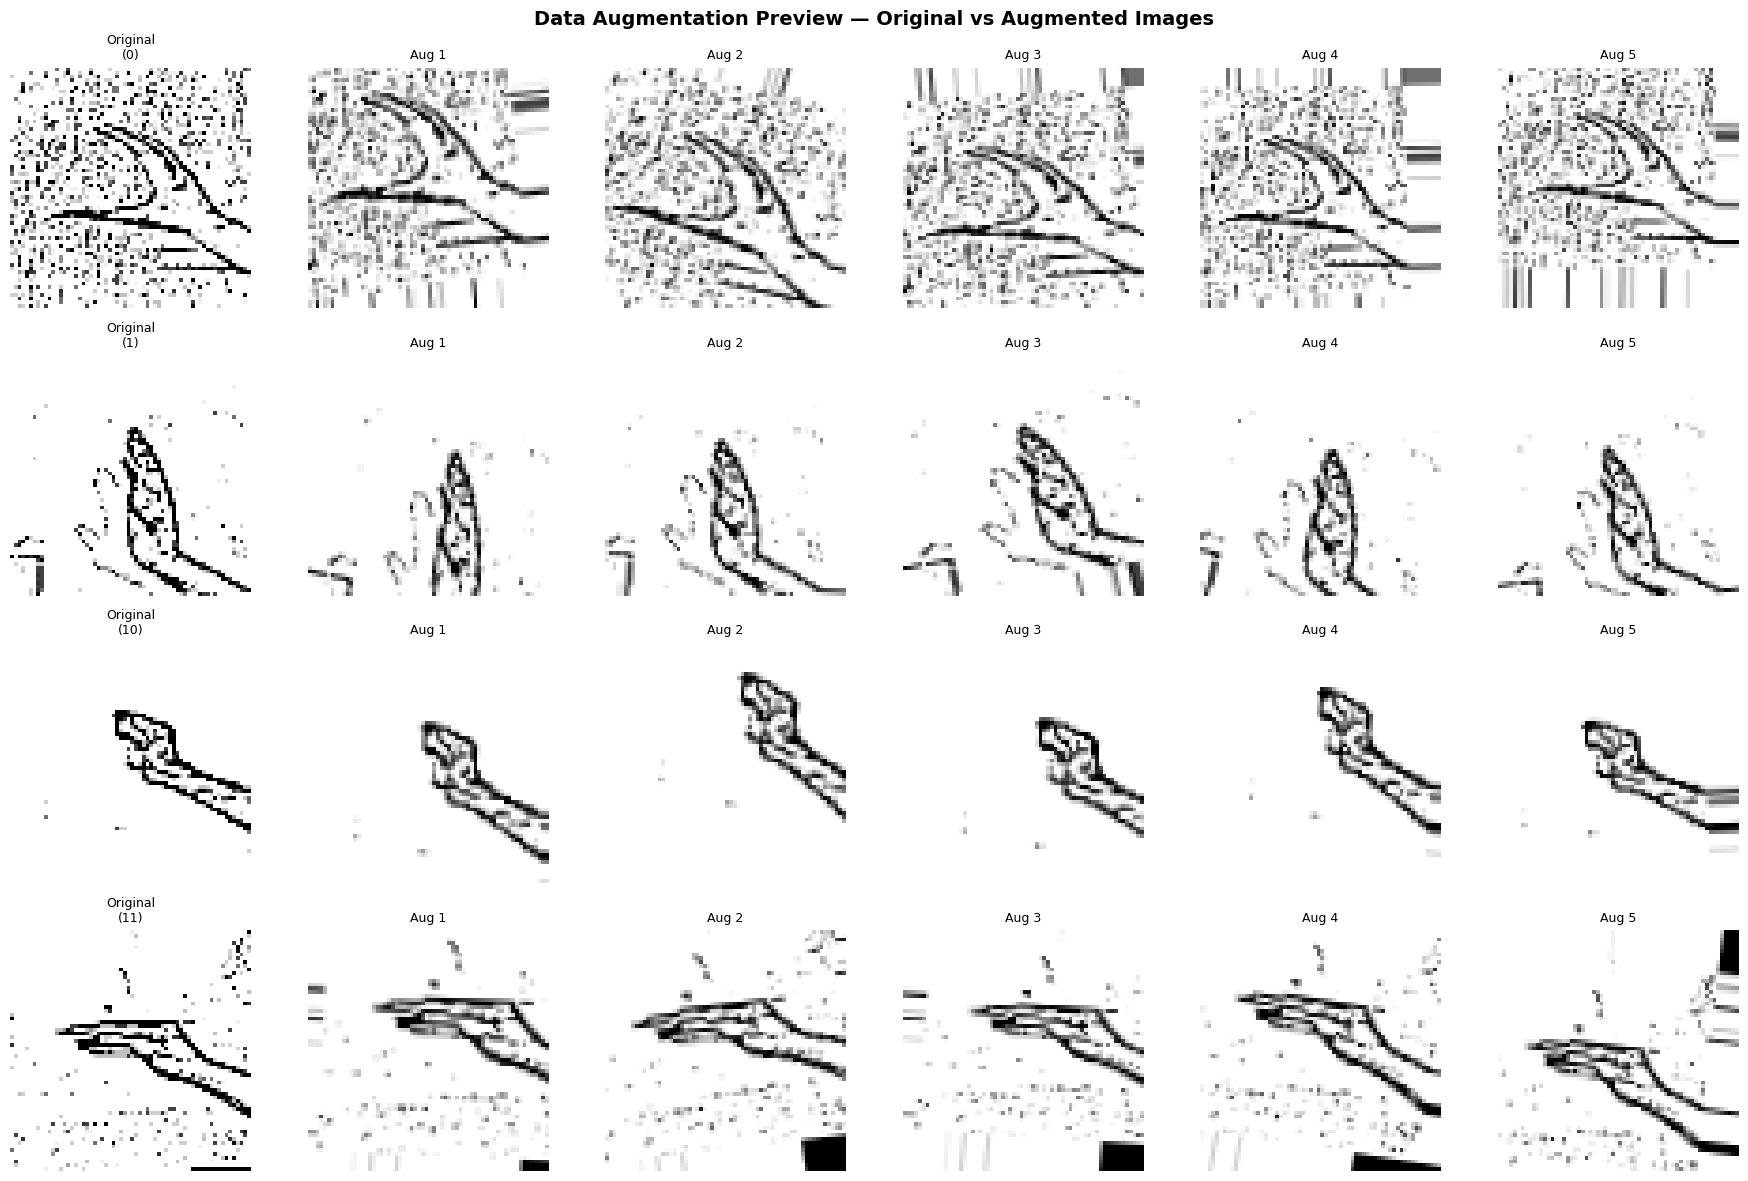

Augmentation preview saved as augmented_preview.png


In [ ]:
# ── Show original + 5 augmented versions for one sample per class ────────────
aug_demo = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.12,
    height_shift_range=0.12,
    zoom_range=0.15,
    shear_range=0.1,
    horizontal_flip=False
)

n_show = min(4, NUM_CLASSES)          # show 4 classes
n_aug  = 5                            # augmented copies per class
fig, axes = plt.subplots(n_show, n_aug + 1, figsize=(3 * (n_aug + 1), 3 * n_show))

y_int = np.argmax(y_train, axis=1)
for row, cls_idx in enumerate(range(n_show)):
    sample = x_train[np.where(y_int == cls_idx)[0][0]]   # one image from class
    orig   = sample.reshape(1, *sample.shape)

    axes[row, 0].imshow(sample.squeeze(), cmap='gray')
    axes[row, 0].set_title(f'Original\n({map_characters[cls_idx]})', fontsize=9)
    axes[row, 0].axis('off')

    aug_iter = aug_demo.flow(orig, batch_size=1)
    for col in range(1, n_aug + 1):
        aug_img = next(aug_iter)[0]
        axes[row, col].imshow(aug_img.squeeze(), cmap='gray')
        axes[row, col].set_title(f'Aug {col}', fontsize=9)
        axes[row, col].axis('off')

plt.suptitle('Data Augmentation Preview — Original vs Augmented Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('augmented_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Augmentation preview saved as augmented_preview.png")


---
## PART A — Building CNNs from Scratch

---

## Section 2.5.2 — Baseline Model
Simple architecture: exactly **3 Convolutional layers** → pooling, then **3 Fully-Connected layers** → output.  
No BatchNormalization or Dropout (kept minimal on purpose to establish a baseline).

In [ ]:
# ── Baseline CNN: 3 Conv + 3 FCN ─────────────────────────────────────────────
def build_baseline_model(num_classes, input_shape=(64, 64, 1)):
    """
    Baseline model with exactly:
      - 3 Convolutional layers (each followed by MaxPooling)
      - 3 Fully Connected (Dense) layers
      - Output layer
    No regularisation (BatchNorm / Dropout) to keep it a true baseline.
    """
    model = Sequential(name='Baseline_CNN')

    # ── Conv Block 1 ──────────────────────────────────────────────────────────
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu',
                     padding='same', input_shape=input_shape))
    model.add(MaxPool2D(pool_size=(2, 2)))

    # ── Conv Block 2 ──────────────────────────────────────────────────────────
    model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
    model.add(MaxPool2D(pool_size=(2, 2)))

    # ── Conv Block 3 ──────────────────────────────────────────────────────────
    model.add(Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'))
    model.add(MaxPool2D(pool_size=(2, 2)))

    # ── Flatten → 3 Fully Connected layers ───────────────────────────────────
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))         # FCN Layer 1
    model.add(Dense(256, activation='relu'))         # FCN Layer 2
    model.add(Dense(128, activation='relu'))         # FCN Layer 3

    # ── Output Layer ──────────────────────────────────────────────────────────
    model.add(Dense(num_classes, activation='softmax'))

    return model

baseline_model = build_baseline_model(num_classes=NUM_CLASSES)
baseline_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,456,614 (17.00 MB)

 Trainable params: 4,456,614 (17.00 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import time

EPOCHS     = 50
BATCH_SIZE = 32

cb_es_base = callbacks.EarlyStopping(monitor='val_accuracy', patience=8,
                                     restore_best_weights=True, verbose=1)
cb_rlr_base = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                          patience=4, min_lr=1e-7, verbose=1)

baseline_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training Baseline Model...")
start_base = time.time()
history_base = baseline_model.fit(
    datagen.flow(x_train, y_train, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(x_test, y_test),
    callbacks=[cb_es_base, cb_rlr_base],
    verbose=1
)
baseline_train_time = time.time() - start_base
print(f"\nBaseline training time: {baseline_train_time:.1f} seconds ({baseline_train_time/60:.1f} min)")


Training Baseline Model...
Epoch 1/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 100s 350ms/step - accuracy: 0.0226 - loss: 3.6393 - val_accuracy: 0.0267 - val_loss: 3.6374 - learning_rate: 0.0010
Epoch 2/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 99s 357ms/step - accuracy: 0.0245 - loss: 3.6388 - val_accuracy: 0.0271 - val_loss: 3.6372 - learning_rate: 0.0010
Epoch 3/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 100s 359ms/step - accuracy: 0.0566 - loss: 3.4997 - val_accuracy: 0.1848 - val_loss: 2.8746 - learning_rate: 0.0010
Epoch 4/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 99s 358ms/step - accuracy: 0.2736 - loss: 2.4458 - val_accuracy: 0.4202 - val_loss: 1.8301 - learning_rate: 0.0010
Epoch 5/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 97s 350ms/step - accuracy: 0.4601 - loss: 1.7271 - val_accuracy: 0.5269 - val_loss: 1.5622 - learning_rate: 0.0010
Epoch 6/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 103s 372ms/step - accuracy: 0.5509 - loss: 1.4176 - val_accuracy: 0.6069 - val_loss: 1.2439 - learning_rate: 0.0010
Epoch 7/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# ── Helper for plotting history ───────────────────────────────────────────────
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot training & validation accuracy values
    ax1.plot(history.history['accuracy'])
    ax1.plot(history.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='upper left')
    ax1.grid(alpha=0.3)

    # Plot training & validation loss values
    ax2.plot(history.history['loss'])
    ax2.plot(history.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper left')
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# ── Evaluate Baseline ─────────────────────────────────────────────────────────
plot_history(history_base)   # reuse helper from Section 10

score_base = baseline_model.evaluate(x_test, y_test, verbose=0)
print(f"Baseline — Test Loss     : {score_base[0]:.4f}")
print(f"Baseline — Test Accuracy : {score_base[1]*100:.2f}%")

y_pred_base = np.argmax(baseline_model.predict(x_test, verbose=0), axis=1)
y_true      = np.argmax(y_test, axis=1)

print("\nClassification Report (Baseline):")
print(metrics.classification_report(y_true, y_pred_base, target_names=class_labels))

cm_base = metrics.confusion_matrix(y_true, y_pred_base)
plt.figure(figsize=(20, 16))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix — Baseline CNN', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('True Label', fontsize=13)
plt.tight_layout()
plt.savefig('cm_baseline.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── Sample Inference on Individual Images (Baseline) ─────────────────────────
n_samples = 12
random_idx = np.random.choice(len(x_test), n_samples, replace=False)

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
axes = axes.flatten()

for i, idx in enumerate(random_idx):
    img   = x_test[idx]
    true  = class_labels[np.argmax(y_test[idx])]
    pred  = class_labels[np.argmax(baseline_model.predict(img[np.newaxis,...], verbose=0))]
    color = 'green' if pred == true else 'red'

    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(f"True: {true}\nPred: {pred}", color=color, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Baseline Model — Sample Inference\n(Green = Correct, Red = Wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_inference.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 2.5.3 — Deeper Architecture with Regularisation
**At least double** the convolutional layers of the baseline (6 conv layers vs 3), plus  
**BatchNormalization** and **Dropout** for regularisation.

In [ ]:
# ── Deeper CNN: 6 Conv blocks + BatchNorm + Dropout ──────────────────────────
def build_deeper_model(num_classes, input_shape=(64, 64, 1)):
    """
    Deeper model (doubles the baseline):
      - 6 Convolutional layers in 3 paired blocks (each block: Conv→BN→Conv→BN→Pool→Dropout)
      - 3 Fully Connected layers with Dropout regularisation
      - Output layer
    Regularisation: BatchNormalization + Dropout
    """
    model = Sequential(name='Deeper_CNN')

    # ── Block 1 (32 filters) ─────────────────────────────────────────────────
    model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPool2D((2,2)))
    model.add(Dropout(0.25))

    # ── Block 2 (64 filters) ─────────────────────────────────────────────────
    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPool2D((2,2)))
    model.add(Dropout(0.25))

    # ── Block 3 (128 filters) ────────────────────────────────────────────────
    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPool2D((2,2)))
    model.add(Dropout(0.25))

    # ── Flatten → 3 Fully Connected layers ───────────────────────────────────
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))

    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.3))

    model.add(Dense(128, activation='relu'))

    # ── Output ────────────────────────────────────────────────────────────────
    model.add(Dense(num_classes, activation='softmax'))

    return model

deeper_model = build_deeper_model(num_classes=NUM_CLASSES)
deeper_model.summary()

# Parameter count comparison
print(f"\nBaseline parameters : {baseline_model.count_params():,}")
print(f"Deeper   parameters : {deeper_model.count_params():,}")


In [ ]:
cb_es_deep  = callbacks.EarlyStopping(monitor='val_accuracy', patience=10,
                                      restore_best_weights=True, verbose=1)
cb_cp_deep  = callbacks.ModelCheckpoint('best_deeper_model.keras',
                                        monitor='val_accuracy', save_best_only=True, verbose=1)
cb_rlr_deep = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                          patience=5, min_lr=1e-7, verbose=1)

deeper_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training Deeper Model (Adam)...")
start_deep = time.time()
history_deep = deeper_model.fit(
    datagen.flow(x_train, y_train, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(x_test, y_test),
    callbacks=[cb_es_deep, cb_cp_deep, cb_rlr_deep],
    verbose=1
)
deeper_train_time = time.time() - start_deep
print(f"\nDeeper model training time: {deeper_train_time:.1f} seconds ({deeper_train_time/60:.1f} min)")


In [ ]:
# ── Evaluate Deeper Model ────────────────────────────────────────────────────
plot_history(history_deep)

score_deep = deeper_model.evaluate(x_test, y_test, verbose=0)
print(f"Deeper — Test Loss     : {score_deep[0]:.4f}")
print(f"Deeper — Test Accuracy : {score_deep[1]*100:.2f}%")

y_pred_deep = np.argmax(deeper_model.predict(x_test, verbose=0), axis=1)

print("\nClassification Report (Deeper):")
print(metrics.classification_report(y_true, y_pred_deep, target_names=class_labels))

cm_deep = metrics.confusion_matrix(y_true, y_pred_deep)
plt.figure(figsize=(20, 16))
sns.heatmap(cm_deep, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix — Deeper CNN', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label'); plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('cm_deeper.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 2.5.4 — Experimentation and Comparative Analysis

In [ ]:
# ── 2.5.4 (1): Baseline vs Deeper — Accuracy, Loss, Training Time ─────────────
print("=" * 60)
print("     COMPARATIVE SUMMARY: BASELINE  vs  DEEPER MODEL")
print("=" * 60)
print(f"{'Metric':<30} {'Baseline':>12} {'Deeper':>12}")
print("-" * 60)
print(f"{'Test Accuracy':<30} {score_base[1]*100:>11.2f}% {score_deep[1]*100:>11.2f}%")
print(f"{'Test Loss':<30} {score_base[0]:>12.4f} {score_deep[0]:>12.4f}")
print(f"{'Training Time (s)':<30} {baseline_train_time:>12.1f} {deeper_train_time:>12.1f}")
print(f"{'Total Parameters':<30} {baseline_model.count_params():>12,} {deeper_model.count_params():>12,}")
print("=" * 60)

# ── Visualise training curves side by side ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].plot(history_base.history['accuracy'],     label='Train', color='steelblue')
axes[0,0].plot(history_base.history['val_accuracy'], label='Val',   color='orange')
axes[0,0].set_title('Baseline — Accuracy', fontweight='bold'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(history_base.history['loss'],     label='Train', color='steelblue')
axes[0,1].plot(history_base.history['val_loss'], label='Val',   color='orange')
axes[0,1].set_title('Baseline — Loss', fontweight='bold'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(history_deep.history['accuracy'],     label='Train', color='green')
axes[1,0].plot(history_deep.history['val_accuracy'], label='Val',   color='red')
axes[1,0].set_title('Deeper — Accuracy', fontweight='bold'); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(history_deep.history['loss'],     label='Train', color='green')
axes[1,1].plot(history_deep.history['val_loss'], label='Val',   color='red')
axes[1,1].set_title('Deeper — Loss', fontweight='bold'); axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

plt.suptitle('Training Curves: Baseline vs Deeper Model', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 2.5.4 (3): Optimizer Analysis — SGD vs Adam
Train the deeper architecture with **SGD** and compare against **Adam**.

In [ ]:
from tensorflow.keras.optimizers import SGD

# ── Train deeper model with SGD ───────────────────────────────────────────────
deeper_sgd = build_deeper_model(num_classes=NUM_CLASSES)
deeper_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),   # momentum helps SGD converge
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_es_sgd = callbacks.EarlyStopping(monitor='val_accuracy', patience=10,
                                    restore_best_weights=True, verbose=1)
cb_rlr_sgd = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                         patience=5, min_lr=1e-6, verbose=1)

print("Training Deeper Model with SGD...")
start_sgd = time.time()
history_sgd = deeper_sgd.fit(
    datagen.flow(x_train, y_train, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(x_test, y_test),
    callbacks=[cb_es_sgd, cb_rlr_sgd],
    verbose=1
)
sgd_train_time = time.time() - start_sgd
score_sgd = deeper_sgd.evaluate(x_test, y_test, verbose=0)

print(f"\nSGD  — Test Loss: {score_sgd[0]:.4f} | Accuracy: {score_sgd[1]*100:.2f}%")
print(f"Adam — Test Loss: {score_deep[0]:.4f} | Accuracy: {score_deep[1]*100:.2f}%")


In [ ]:
# ── SGD vs Adam comparison plot ───────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(history_deep.history['val_accuracy'], label='Adam',  color='royalblue', linewidth=2)
ax1.plot(history_sgd.history['val_accuracy'],  label='SGD',   color='tomato',    linewidth=2)
ax1.set_title('Optimizer Comparison — Validation Accuracy', fontweight='bold', fontsize=13)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Validation Accuracy')
ax1.legend(fontsize=12); ax1.grid(alpha=0.3)

ax2.plot(history_deep.history['val_loss'], label='Adam', color='royalblue', linewidth=2)
ax2.plot(history_sgd.history['val_loss'],  label='SGD',  color='tomato',    linewidth=2)
ax2.set_title('Optimizer Comparison — Validation Loss', fontweight='bold', fontsize=13)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Validation Loss')
ax2.legend(fontsize=12); ax2.grid(alpha=0.3)

plt.suptitle('SGD vs Adam — Deeper Model', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('sgd_vs_adam.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Optimizer Summary ────────────────────────────────────────────────")
print(f"{'Optimizer':<12} {'Val Accuracy':>14} {'Training Time':>15}")
print("-" * 45)
print(f"{'Adam':<12} {score_deep[1]*100:>13.2f}% {deeper_train_time:>14.1f}s")
print(f"{'SGD':<12} {score_sgd[1]*100:>13.2f}% {sgd_train_time:>14.1f}s")


## 2.5.4 (4): Ablation Study — Removing Dropout
Remove **Dropout** layers from the deeper architecture and measure impact.

In [ ]:
# ── Deeper model WITHOUT Dropout ──────────────────────────────────────────────
def build_no_dropout_model(num_classes, input_shape=(64, 64, 1)):
    """Identical to Deeper model but with all Dropout layers removed."""

    model = Sequential(name='NoBN_Dropout_Ablation')

    model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPool2D((2,2)))
    # Dropout(0.25) REMOVED

    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPool2D((2,2)))

    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPool2D((2,2)))

    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    # Dropout(0.5) REMOVED
    model.add(Dense(256, activation='relu'))
    # Dropout(0.3) REMOVED
    model.add(Dense(128, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    return model

ablation_model = build_no_dropout_model(num_classes=NUM_CLASSES)
ablation_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_es_abl = callbacks.EarlyStopping(monitor='val_accuracy', patience=8,
                                    restore_best_weights=True, verbose=1)
print("Training Ablation Model (No Dropout)...")
history_ablation = ablation_model.fit(
    datagen.flow(x_train, y_train, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(x_test, y_test),
    callbacks=[cb_es_abl],
    verbose=1
)
score_abl = ablation_model.evaluate(x_test, y_test, verbose=0)

print(f"\nAblation (No Dropout) — Accuracy: {score_abl[1]*100:.2f}%")
print(f"Deeper (With Dropout) — Accuracy: {score_deep[1]*100:.2f}%")

# Plot overfitting comparison
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history_deep.history['accuracy'],      label='Deeper (Train, With Dropout)',  color='green',    linewidth=2)
ax.plot(history_deep.history['val_accuracy'],  label='Deeper (Val, With Dropout)',    color='green',    linewidth=2, linestyle='--')
ax.plot(history_ablation.history['accuracy'],  label='Ablation (Train, No Dropout)', color='orange',   linewidth=2)
ax.plot(history_ablation.history['val_accuracy'], label='Ablation (Val, No Dropout)', color='orange', linewidth=2, linestyle='--')
ax.set_title('Ablation Study — Effect of Removing Dropout', fontweight='bold', fontsize=13)
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()


---
## PART B — Transfer Learning (Fine-Tuning a Pre-Trained Model)

---

## Section 2.6 — MobileNetV2 Fine-Tuning
Uses **MobileNetV2** pre-trained on ImageNet.  
Input images are resized to **96×96** (MobileNetV2 minimum) with 3 channels for compatibility.

In [ ]:
# ── Resize images to 96×96 RGB for MobileNetV2 ───────────────────────────────
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import GlobalAveragePooling2D

TL_IMG_SIZE = 96   # MobileNetV2 minimum is 96x96

def load_images_rgb(data_folder=DATA_FOLDER, img_size=TL_IMG_SIZE):
    """Load images as RGB (3 channels) resized to img_size for transfer learning."""

    images, labels = [], []
    folders = sorted(os.listdir(data_folder))
    for index, folder in enumerate(folders):
        folder_path = os.path.join(data_folder, folder)
        if not os.path.isdir(folder_path):
            continue
        print(f'[{index+1}/{len(folders)}] Loading "{folder}" ...')
        for fname in os.listdir(folder_path):
            img = cv2.imread(os.path.join(folder_path, fname))
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            images.append(img)
            labels.append(index)

    images = np.array(images, dtype='float32') / 255.0
    labels = to_categorical(labels, num_classes=len(folders))

    x_tr, x_te, y_tr, y_te = train_test_split(
        images, labels, test_size=0.2, random_state=42, stratify=labels
    )
    print(f'\nRGB Data — Train: {x_tr.shape}  |  Test: {x_te.shape}')
    return x_tr, x_te, y_tr, y_te

x_train_rgb, x_test_rgb, y_train_rgb, y_test_rgb = load_images_rgb()
x_train_rgb, y_train_rgb = shuffle(x_train_rgb, y_train_rgb, random_state=17)


In [ ]:
# ── Build MobileNetV2 Transfer Learning Model ─────────────────────────────────
base_model = MobileNetV2(
    input_shape=(TL_IMG_SIZE, TL_IMG_SIZE, 3),
    include_top=False,           # Remove ImageNet output layer
    weights='imagenet'
)

# Phase 1 — Feature Extraction: freeze the convolutional base
base_model.trainable = False
print(f"MobileNetV2 base layers : {len(base_model.layers)}")
print(f"Trainable layers frozen : all (feature extraction phase)")

# Add custom classification head
inputs  = Input(shape=(TL_IMG_SIZE, TL_IMG_SIZE, 3))
x       = base_model(inputs, training=False)
x       = GlobalAveragePooling2D()(x)
x       = Dense(256, activation='relu')(x)
x       = Dropout(0.4)(x)
x       = Dense(128, activation='relu')(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = Model(inputs, outputs, name='MobileNetV2_TransferLearning')
tl_model.summary()

print(f"\nTotal parameters     : {tl_model.count_params():,}")
print(f"Trainable parameters : {sum(tf.size(w).numpy() for w in tl_model.trainable_weights):,}")


In [ ]:
# ── Phase 1 Training: Feature Extraction (frozen base) ───────────────────────
datagen_rgb = ImageDataGenerator(
    rotation_range=10, width_shift_range=0.1,
    height_shift_range=0.1, zoom_range=0.1,
    horizontal_flip=False
)
datagen_rgb.fit(x_train_rgb)

tl_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_es_tl  = callbacks.EarlyStopping(monitor='val_accuracy', patience=8,
                                    restore_best_weights=True, verbose=1)
cb_rlr_tl = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                        patience=4, min_lr=1e-7, verbose=1)

print("Phase 1 — Training classification head (base frozen)...")
start_tl = time.time()
history_tl_phase1 = tl_model.fit(
    datagen_rgb.flow(x_train_rgb, y_train_rgb, batch_size=BATCH_SIZE),
    epochs=20,
    validation_data=(x_test_rgb, y_test_rgb),
    callbacks=[cb_es_tl, cb_rlr_tl],
    verbose=1
)
print(f"Phase 1 done in {time.time()-start_tl:.1f}s")


In [ ]:
# ── Phase 2 Fine-Tuning: Unfreeze top 30 layers ───────────────────────────────
base_model.trainable = True
# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Layers unfrozen for fine-tuning: {trainable_count} / {len(base_model.layers)}")

tl_model.compile(
    optimizer=Adam(learning_rate=1e-5),   # very low LR to avoid catastrophic forgetting
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_es_tl2  = callbacks.EarlyStopping(monitor='val_accuracy', patience=10,
                                     restore_best_weights=True, verbose=1)
cb_cp_tl   = callbacks.ModelCheckpoint('best_tl_model.keras',
                                       monitor='val_accuracy', save_best_only=True, verbose=1)

print("Phase 2 — Fine-tuning top layers with very low LR...")
start_ft = time.time()
history_tl_phase2 = tl_model.fit(
    datagen_rgb.flow(x_train_rgb, y_train_rgb, batch_size=BATCH_SIZE),
    epochs=30,
    validation_data=(x_test_rgb, y_test_rgb),
    callbacks=[cb_es_tl2, cb_cp_tl],
    verbose=1
)
tl_total_time = time.time() - start_tl
print(f"Phase 2 done. Total TL training time: {tl_total_time:.1f}s ({tl_total_time/60:.1f} min)")


In [ ]:
# ── Evaluate Transfer Learning Model ─────────────────────────────────────────
# Plot both phases
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

all_acc = (history_tl_phase1.history['val_accuracy'] +
           history_tl_phase2.history['val_accuracy'])
all_loss = (history_tl_phase1.history['val_loss'] +
            history_tl_phase2.history['val_loss'])
n_phase1 = len(history_tl_phase1.history['val_accuracy'])

axes[0].plot(all_acc, label='Val Accuracy', color='purple', linewidth=2)
axes[0].axvline(n_phase1, color='gray', linestyle='--', label=f'Fine-tuning start (ep {n_phase1})')
axes[0].set_title('MobileNetV2 — Validation Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(all_loss, label='Val Loss', color='purple', linewidth=2)
axes[1].axvline(n_phase1, color='gray', linestyle='--', label=f'Fine-tuning start (ep {n_phase1})')
axes[1].set_title('MobileNetV2 — Validation Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Transfer Learning — Phase 1 (Feature Extraction) + Phase 2 (Fine-Tuning)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tl_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Metrics ───────────────────────────────────────────────────────────────────
score_tl = tl_model.evaluate(x_test_rgb, y_test_rgb, verbose=0)
print(f"Transfer Learning — Test Loss     : {score_tl[0]:.4f}")
print(f"Transfer Learning — Test Accuracy : {score_tl[1]*100:.2f}%")

y_pred_tl   = np.argmax(tl_model.predict(x_test_rgb, verbose=0), axis=1)
y_true_rgb  = np.argmax(y_test_rgb, axis=1)

print("\nClassification Report (Transfer Learning):")
print(metrics.classification_report(y_true_rgb, y_pred_tl, target_names=class_labels))

cm_tl = metrics.confusion_matrix(y_true_rgb, y_pred_tl)
plt.figure(figsize=(20, 16))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix — MobileNetV2 (Transfer Learning)', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label'); plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('cm_transfer_learning.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
# ── Sample Inference — Transfer Learning Model ────────────────────────────────
n_samples  = 12
random_idx = np.random.choice(len(x_test_rgb), n_samples, replace=False)

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
axes = axes.flatten()

for i, idx in enumerate(random_idx):
    img  = x_test_rgb[idx]
    true = class_labels[np.argmax(y_test_rgb[idx])]
    pred = class_labels[np.argmax(tl_model.predict(img[np.newaxis,...], verbose=0))]
    color = 'green' if pred == true else 'red'

    axes[i].imshow(img)
    axes[i].set_title(f"True: {true}\nPred: {pred}", color=color, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Transfer Learning (MobileNetV2) — Sample Inference\n(Green = Correct, Red = Wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tl_inference.png', dpi=150, bbox_inches='tight')
plt.show()


## Final Overall Comparison — All Models

In [ ]:
# ── Final Summary Table ───────────────────────────────────────────────────────
models_summary = {
    'Baseline CNN':            {'acc': score_base[1]*100, 'loss': score_base[0], 'time': baseline_train_time, 'params': baseline_model.count_params()},
    'Deeper CNN (Adam)':       {'acc': score_deep[1]*100, 'loss': score_deep[0], 'time': deeper_train_time,  'params': deeper_model.count_params()},
    'Deeper CNN (SGD)':        {'acc': score_sgd[1]*100,  'loss': score_sgd[0],  'time': sgd_train_time,     'params': deeper_sgd.count_params()},
    'Ablation (No Dropout)':   {'acc': score_abl[1]*100,  'loss': score_abl[0],  'time': 0,                  'params': ablation_model.count_params()},
    'MobileNetV2 (TL)':        {'acc': score_tl[1]*100,   'loss': score_tl[0],   'time': tl_total_time,      'params': tl_model.count_params()},
}

print("\n" + "=" * 80)
print(f"  {'Model':<28} {'Accuracy':>10} {'Loss':>8} {'Time (s)':>10} {'Params':>12}")
print("=" * 80)
for name, v in models_summary.items():
    print(f"  {name:<28} {v['acc']:>9.2f}% {v['loss']:>8.4f} {v['time']:>10.1f} {v['params']:>12,}")
print("=" * 80)

# ── Bar chart comparison ───────────────────────────────────────────────────────
names  = list(models_summary.keys())
accs   = [v['acc'] for v in models_summary.values()]
colors = ['#4c72b0', '#55a868', '#c44e52', '#dd8452', '#8172b2']

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(names, accs, color=colors, edgecolor='black', linewidth=0.7)
ax.set_ylim(0, 110)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Model Comparison — Test Accuracy Across All Architectures',
             fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=15)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{acc:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Save All Models

In [ ]:
baseline_model.save('Baseline_CNN.keras')
deeper_model.save('Deeper_CNN_Adam.keras')
tl_model.save('MobileNetV2_TL.keras')
print("All models saved successfully.")

# Optionally save to Google Drive
for fname in ['Baseline_CNN.keras', 'Deeper_CNN_Adam.keras', 'MobileNetV2_TL.keras']:
    try:
        import shutil
        shutil.copy(fname, f'/content/drive/MyDrive/{fname}')
        print(f"  Copied {fname} to Google Drive")
    except Exception as e:
        print(f"  Could not copy {fname} to Drive: {e}")
